In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import acf
from scipy.signal import find_peaks

from config import AGGREGATIONS, BENCHMARKS, RANDOM_SEED
from utils import load_dataset, plot_pool_distribution, print_summary, SOURCE_MAP
from scoring.runner import score_source, scores_path
from selection import select_source, save_selection

AGGREGATION = "10min"
BENCHMARK = "PERIODIC_SPACES"
AGG_PARAMS = AGGREGATIONS[AGGREGATION]
BENCH_PARAMS = BENCHMARKS[BENCHMARK]
STEP_MINUTES = 24 * 60 // AGG_PARAMS["daily_period"]

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

print(f"Benchmark: {BENCHMARK}")
print(f"Aggregation: {AGGREGATION}")
print(f"Threshold: {BENCH_PARAMS['metric_col']} {BENCH_PARAMS['metric_op']} {BENCH_PARAMS['threshold']}")
print(f"Sparsity band: [{BENCH_PARAMS['sparsity_min']}, {BENCH_PARAMS.get('sparsity_max', 1.0)}]")
print(f"Sample size: {BENCH_PARAMS['sample_size']} | Seed: {RANDOM_SEED}")

Benchmark: PERIODIC_SPACES
Aggregation: 10min
Threshold: max_acf >= 0.6
Sparsity band: [0.05, 0.95]
Sample size: 25 | Seed: 42


## 1 — Scoring

Detect periodic zero/non-zero patterns via ACF on the binarised series.
A binary indicator $B_t = 1$ if `n_bytes = 0`, else $0$, is computed and its ACF analysed for peaks.
If a score file already exists it is loaded from disk; otherwise `score_source` runs the full computation.

In [2]:
sources = BENCH_PARAMS["levels"]
scores = {}

for source in sources:
    path = scores_path(AGGREGATION, BENCHMARK, source)
    if os.path.exists(path):
        print(f"Loading existing scores: {path}")
        scores[source] = pd.read_csv(path)
    else:
        print(f"Computing scores for {source}...")
        scores[source] = score_source(BENCHMARK, source, aggregation=AGGREGATION)

for source, df in scores.items():
    print(f"\n{source}: {len(df)} series scored")
    display(df.describe().round(3))

Loading existing scores: scores/10min/PERIODIC_SPACES_ips.csv

ips: 1000 series scored


,id_ip,ratio_active,max_acf,dominant_lag
count,1000.000,1000.000,471.000,471.000
mean,860461.454,0.170,0.161,246.130
std,679140.522,0.265,0.178,379.444
min,11.000,0.003,0.000,0.000
25%,266825.500,0.019,0.000,0.000
50%,635072.500,0.055,0.130,140.000
75%,1629478.250,0.155,0.280,145.000
max,2044888.000,1.000,0.774,1153.000


## 2 — Score distributions

Histogram of `max_acf` (peak ACF of binary indicator) with the selection threshold overlaid.

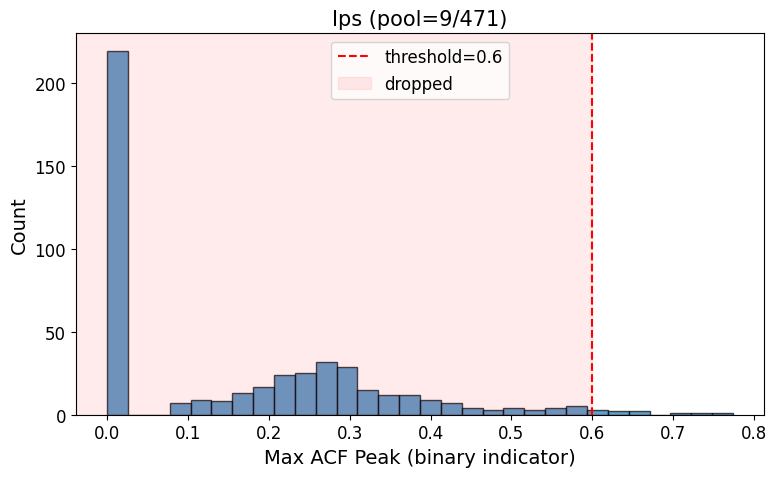

In [3]:
_smin = BENCH_PARAMS["sparsity_min"]
_smax = BENCH_PARAMS.get("sparsity_max", 1.0)
active_scores = {
    s: scores[s][(scores[s]["ratio_active"] >= _smin) & (scores[s]["ratio_active"] <= _smax)]
    for s in sources
}

plot_pool_distribution(
    [(active_scores[s], s.capitalize()) for s in sources],
    metric_col=BENCH_PARAMS["metric_col"],
    threshold=BENCH_PARAMS["threshold"],
    xlabel="Max ACF Peak (binary indicator)",
)

## 3 — Selection

Apply sparsity band filter, threshold filter on `max_acf`, then random sample from the qualifying pool.

In [4]:
selected = {}
pool_sizes = {}

for source in sources:
    ids, pool_size, _ = select_source(BENCHMARK, source, AGGREGATION)
    selected[source] = ids
    pool_sizes[source] = pool_size

print_summary(
    BENCHMARK,
    selected,
    pool_sizes,
    threshold=BENCH_PARAMS["threshold"],
    threshold_name=BENCH_PARAMS["metric_col"],
    sample_size=BENCH_PARAMS["sample_size"],
    seed=RANDOM_SEED,
    extra_info=f"Sparsity band: [{BENCH_PARAMS['sparsity_min']}, {BENCH_PARAMS.get('sparsity_max', 1.0)}]",
)

  ips: 471/1000 pass sparsity, pool=9 — pool exhausted, taking all 9

PERIODIC_SPACES BENCHMARK - Selected Series
Threshold: max_acf >= 0.6
Selection: Random sample of 25 from qualifying pool
Sparsity band: [0.05, 0.95]
Random seed: 42

ips (9): [1385, 1845, 5101, 11204, 334600, 594145, 720439, 722293, 1563916]
  Pool size: 9


### IP sample pool exhausted — fall back to full IP dataset

In [5]:
path = scores_path(AGGREGATION, BENCHMARK, "ips_full")
if os.path.exists(path):
    print(f"Loading existing scores: {path}")
    scores["ips_full"] = pd.read_csv(path)
else:
    print(f"Computing scores for ips_full (chunked)...")
    scores["ips_full"] = score_source(BENCHMARK, "ips_full", aggregation=AGGREGATION)

print(f"\nips_full: {len(scores['ips_full'])} series scored")
display(scores["ips_full"].describe().round(3))

ids, pool_size, _ = select_source(BENCHMARK, "ips_full", AGGREGATION)
selected["ips"] = ids
pool_sizes["ips"] = pool_size

print(f"\nips selected from full dataset ({len(ids)}): {ids}")
print(f"Pool size: {pool_size}")

Loading existing scores: scores/10min/PERIODIC_SPACES_ips_full.csv

ips_full: 275124 series scored


,id_ip,ratio_active,max_acf,dominant_lag
count,275124.000,275124.000,275124.000,275124.000
mean,883801.658,0.150,0.102,210.093
std,666745.924,0.236,0.150,380.550
min,3.000,0.000,0.000,0.000
25%,293947.500,0.019,0.000,0.000
50%,650919.500,0.051,0.000,0.000
75%,1623585.000,0.138,0.214,144.000
max,2055783.000,1.000,0.955,2006.000


  ips_full: 133780/275124 pass sparsity, pool=1580 — selected 25

ips selected from full dataset (25): [10114, 10347, 19798, 105731, 137398, 210681, 219080, 223496, 224079, 230203, 288065, 292005, 293673, 324745, 355858, 377858, 479727, 620344, 630736, 699221, 766565, 849573, 1861858, 1933649, 2003176]
Pool size: 1580


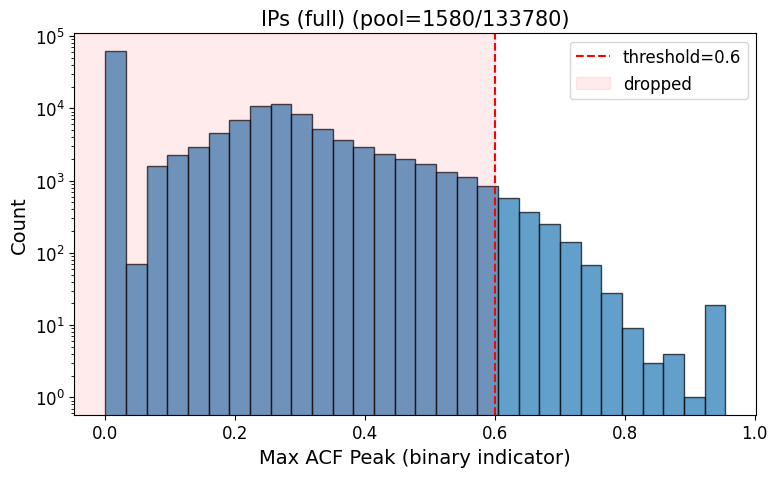

In [6]:
_full_active = scores["ips_full"][
    (scores["ips_full"]["ratio_active"] >= _smin)
    & (scores["ips_full"]["ratio_active"] <= _smax)
]
plot_pool_distribution(
    [(_full_active, "IPs (full)")],
    metric_col=BENCH_PARAMS["metric_col"],
    threshold=BENCH_PARAMS["threshold"],
    xlabel="Max ACF Peak (binary indicator)",
    log_y=True,
)

## 4 — Detailed scores for selected series

In [7]:
for source in sources:
    _, id_col = SOURCE_MAP[source]
    score_key = "ips_full" if source == "ips" and "ips_full" in scores else source
    df_s = scores[score_key]
    sel = df_s[df_s[id_col].isin(selected[source])].sort_values("max_acf", ascending=False)
    print(f"\n{source.capitalize()} — selected series scores:")
    display(sel)


Ips — selected series scores:


,id_ip,ratio_active,max_acf,dominant_lag
52688,219080.0,0.260534,0.821201,2
34733,137398.0,0.063055,0.719602,142
133946,630736.0,0.191697,0.711331,1008
53752,224079.0,0.227083,0.708321,1008
67522,288065.0,0.098193,0.701246,1008
270752,1861858.0,0.161993,0.700987,143
272091,1933649.0,0.141918,0.700936,1007
3161,10347.0,0.204675,0.695380,1008
68342,292005.0,0.095712,0.692559,1008
132095,620344.0,0.193161,0.668255,1008


## 5 — Verification plots

For a few selected series: raw time series, binary indicator, and ACF correlogram of the binary series with peaks marked.

In [8]:
scale = AGG_PARAMS["daily_period"] / 24
MAX_LAG = int(BENCH_PARAMS["max_lag_factor"] * scale)
ACF_THRESHOLD = BENCH_PARAMS["threshold"]
PEAK_PROMINENCE = BENCH_PARAMS["peak_prominence"]
DAILY_PERIOD = AGG_PARAMS["daily_period"]


def plot_periodic_verification(df, id_col, ts_id, level_label):
    grp = df[df[id_col] == ts_id].reset_index(drop=True)
    t = grp["datetime"]
    y = grp["n_bytes"].astype(float).values

    binary = (y == 0).astype(float)
    acf_vals = acf(binary, nlags=MAX_LAG, fft=True)
    peaks, _ = find_peaks(acf_vals, prominence=PEAK_PROMINENCE)
    if len(peaks) > 0:
        best = np.argmax(acf_vals[peaks])
        max_acf = float(acf_vals[peaks[best]])
        dominant_lag = int(peaks[best])
    else:
        max_acf = 0.0
        dominant_lag = 0
    ratio_zeros = float(binary.mean())
    dominant_lag_hours = dominant_lag * STEP_MINUTES / 60

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    axes[0].plot(t, y, linewidth=0.3, alpha=0.7)
    p99 = np.percentile(y[y > 0], 99) if (y > 0).any() else y.max()
    axes[0].set_ylim(-p99 * 0.03, p99 * 1.1)
    axes[0].set_title(f"{level_label} | ID = {int(ts_id)}  —  Raw n_bytes")
    axes[0].set_ylabel("n_bytes")
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t, binary, linewidth=0.3, color="steelblue")
    axes[1].set_title(r"Binary indicator ($B_t = 1$ if n_bytes = 0, else 0)")
    axes[1].set_ylabel(r"$B_t$")
    axes[1].set_ylim(-0.05, 1.1)
    axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    axes[1].grid(True, alpha=0.3)

    lags = np.arange(1, len(acf_vals))
    axes[2].bar(lags, acf_vals[1:], width=1, alpha=0.7, color="steelblue")
    axes[2].axhline(ACF_THRESHOLD, color="red", linestyle="--", alpha=0.7,
                    label=f"threshold={ACF_THRESHOLD}")
    if dominant_lag > 0:
        axes[2].axvline(dominant_lag, color="orange", linestyle="-", alpha=0.8,
                        label=f"dominant lag={dominant_lag_hours:.0f}h ({dominant_lag} steps)")
    for d_line in range(1, MAX_LAG // DAILY_PERIOD + 1):
        axes[2].axvline(d_line * DAILY_PERIOD, color="gray", linestyle=":", alpha=0.3)
    axes[2].set_title(
        f"ACF of binary indicator | "
        f"max_acf={max_acf:.3f} at lag={dominant_lag_hours:.0f}h | "
        f"zero ratio={ratio_zeros:.1%}"
    )
    axes[2].set_ylabel("ACF")
    axes[2].set_xlabel(f"Lag ({STEP_MINUTES}-min steps)")
    axes[2].legend()

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

100%|████████████████████████████| 3/3 [00:07<00:00,  2.66s/it]



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.IP_ADDRESSES_FULL

    Time series
        Time series IDS: [479727  19798 630736], Length=3
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
        Test ba

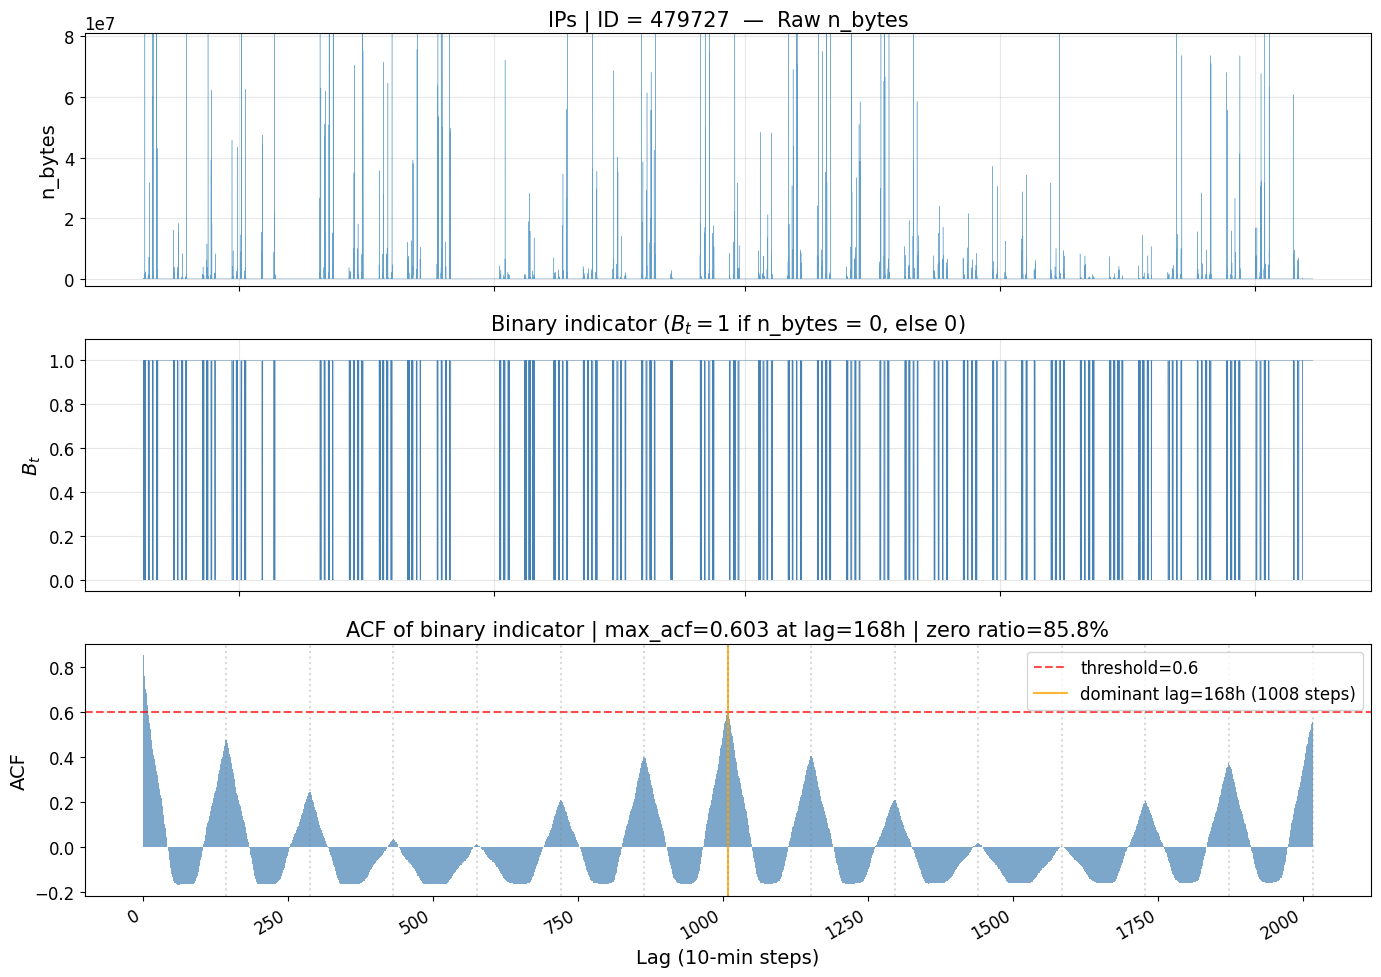

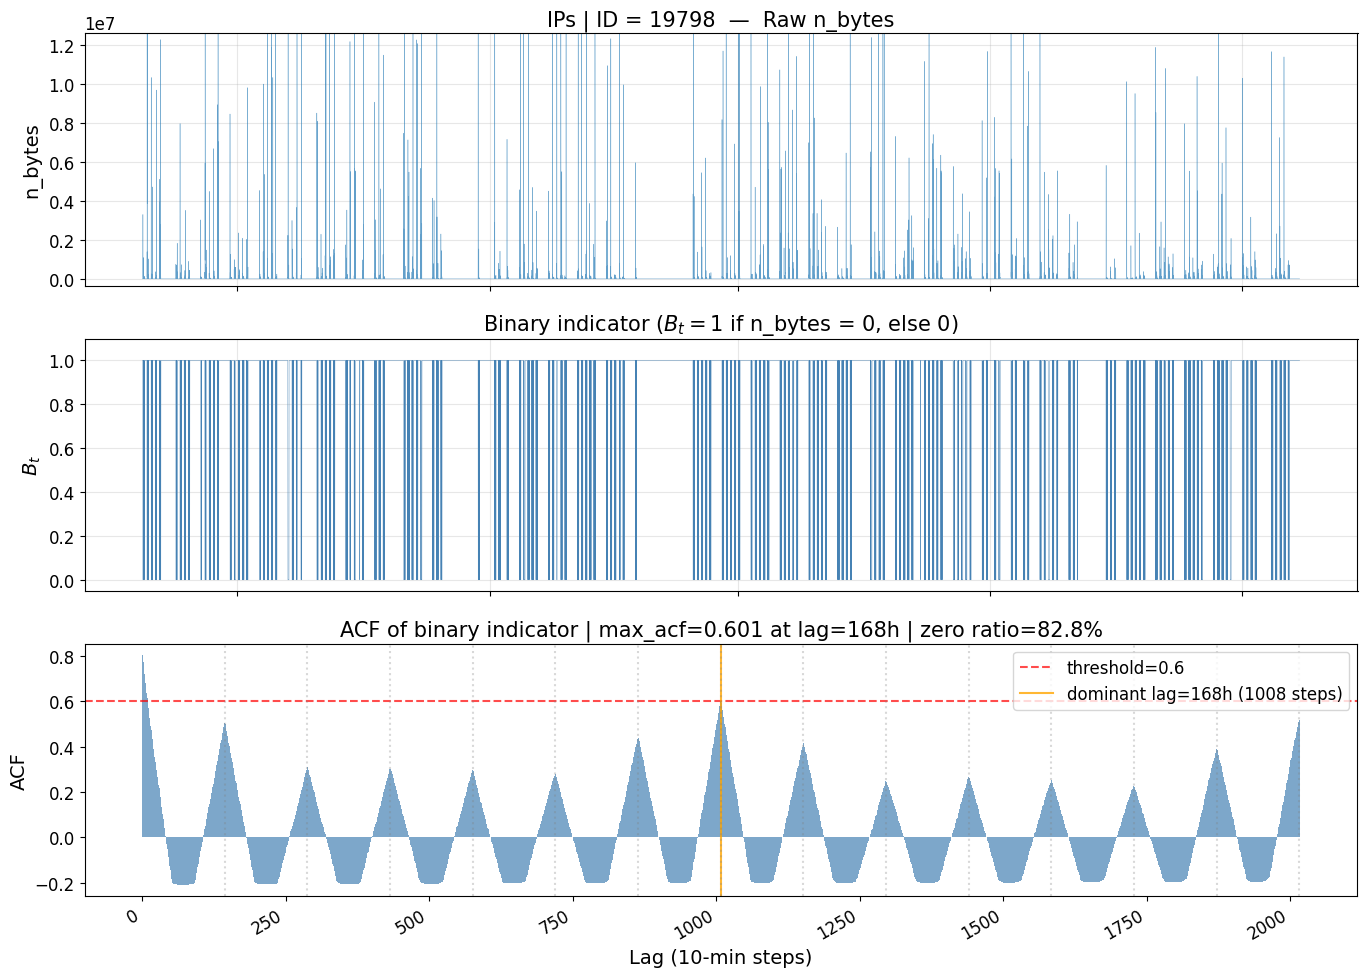

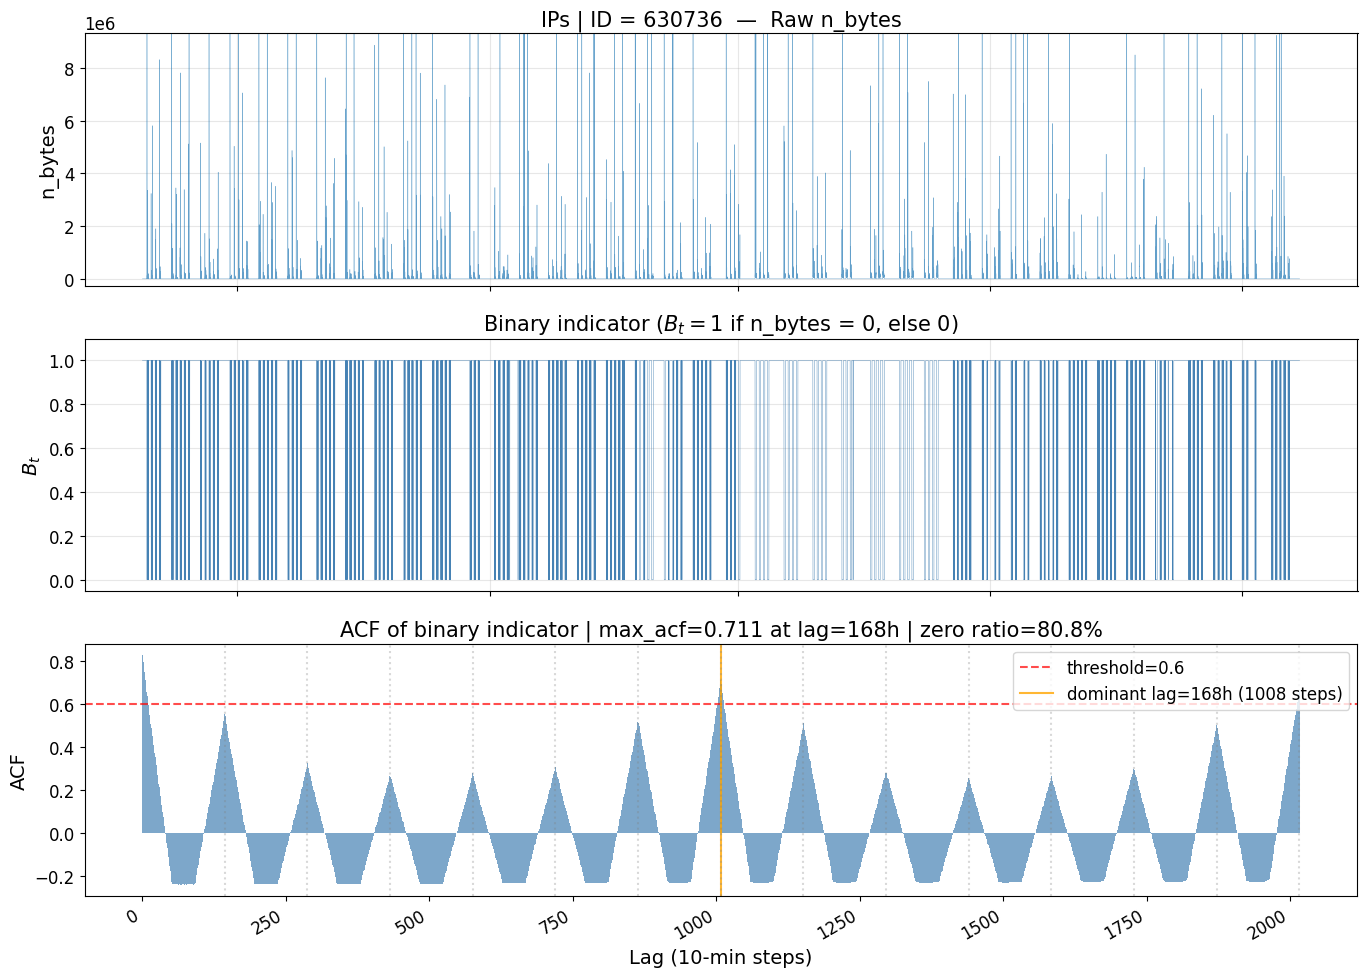

In [9]:
N_VERIFY = 3
rng = np.random.default_rng(RANDOM_SEED)
level_labels = {"institutions": "Institutions", "subnets": "Subnets", "ips": "IPs"}

for source in sources:
    _, id_col = SOURCE_MAP[source]
    load_source = "ips_full" if source == "ips" and "ips_full" in scores else source
    verify_ids = rng.choice(selected[source], size=min(N_VERIFY, len(selected[source])), replace=False).tolist()
    data = load_dataset(load_source, aggregation=AGG_PARAMS["enum"], time_range=AGG_PARAMS["time_range"], ts_ids=verify_ids)
    df = data["df"]
    label = level_labels[source]
    print(f"\n{'='*60}")
    print(f"{source.upper()} — verifying {len(verify_ids)} series")
    print(f"{'='*60}")
    for ts_id in verify_ids:
        plot_periodic_verification(df, id_col, ts_id, label)

## 6 — Save selection

In [10]:
save_selection(selected, BENCHMARK, AGGREGATION)

Saved selected_ids/10min/PERIODIC_SPACES.csv (25 series)


'selected_ids/10min/PERIODIC_SPACES.csv'